In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

print("Notebook Working")


Matplotlib is building the font cache; this may take a moment.


Notebook Working


In [2]:
fund = pd.read_csv("../data/processed/01_fund_master.csv")
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
cat = pd.read_csv("../data/processed/05_category_inflows.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")
perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/investor_transactions_clean.csv")
hold = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

print("All datasets loaded successfully")


All datasets loaded successfully


In [3]:
print(nav.shape)
print(txn.shape)
print(perf.shape)

(46000, 3)
(32778, 13)
(40, 20)


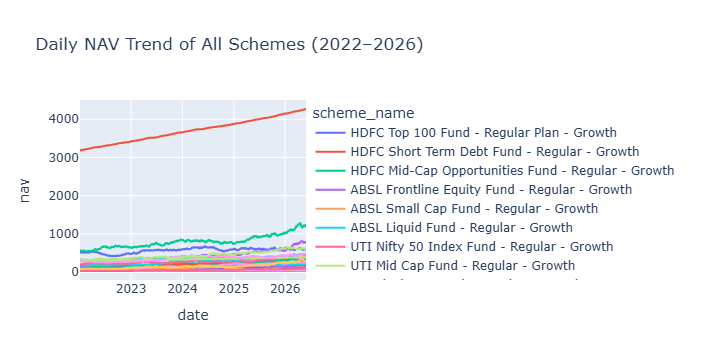

In [11]:
nav["date"] = pd.to_datetime(nav["date"])

nav_plot = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Schemes (2022–2026)"
)

fig.show()

### Insight 1

Kotak Liquid Fund maintained the highest NAV among all schemes throughout the analysis period, significantly exceeding other funds in absolute NAV value.

### Insight 2

Most equity-oriented schemes exhibited steady NAV growth between 2022 and 2026, indicating positive long-term market performance.

In [5]:
import os

os.makedirs("../reports/charts", exist_ok=True)

print("Charts folder created")

Charts folder created


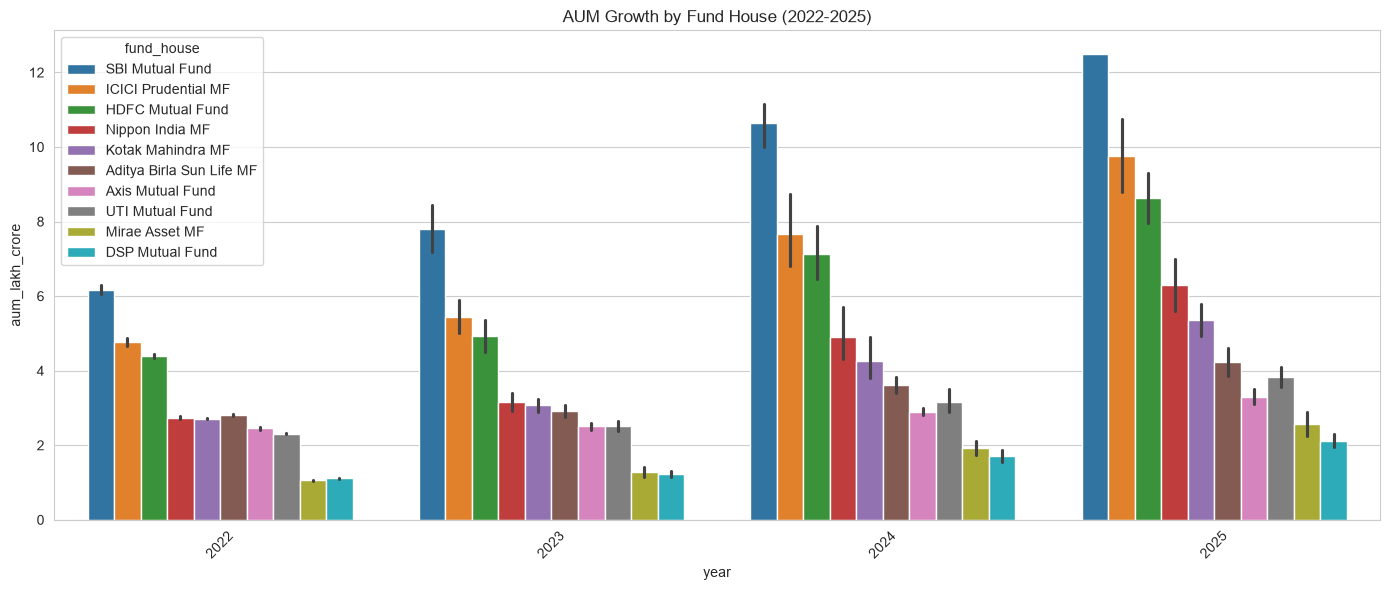

In [10]:
aum["year"] = pd.to_datetime(
    aum["date"]
).dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png"
)

plt.show()


### Insight 3

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses, reaching approximately ₹12.5 lakh crore by 2025.

### Insight 4

All major fund houses recorded steady AUM growth from 2022 to 2025, reflecting increasing investor participation in mutual funds.

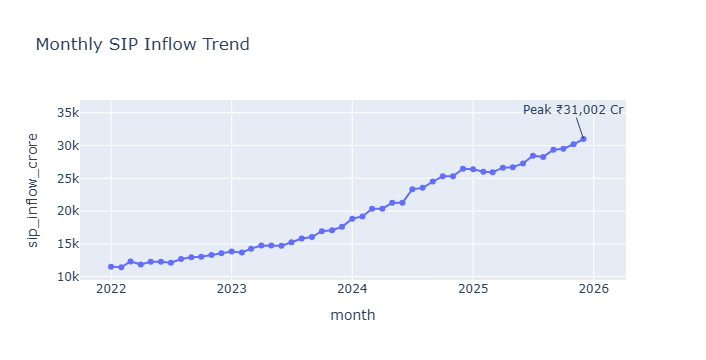

In [7]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend"
)

max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak ₹{max_row['sip_inflow_crore']:,} Cr"
)

fig.show()

### Insight 5

Monthly SIP inflows increased consistently from 2022 to 2025, demonstrating strong growth in retail investor participation.

### Insight 6

SIP inflows reached an all-time high of ₹31,002 crore in December 2025, highlighting growing investor confidence in systematic investing.

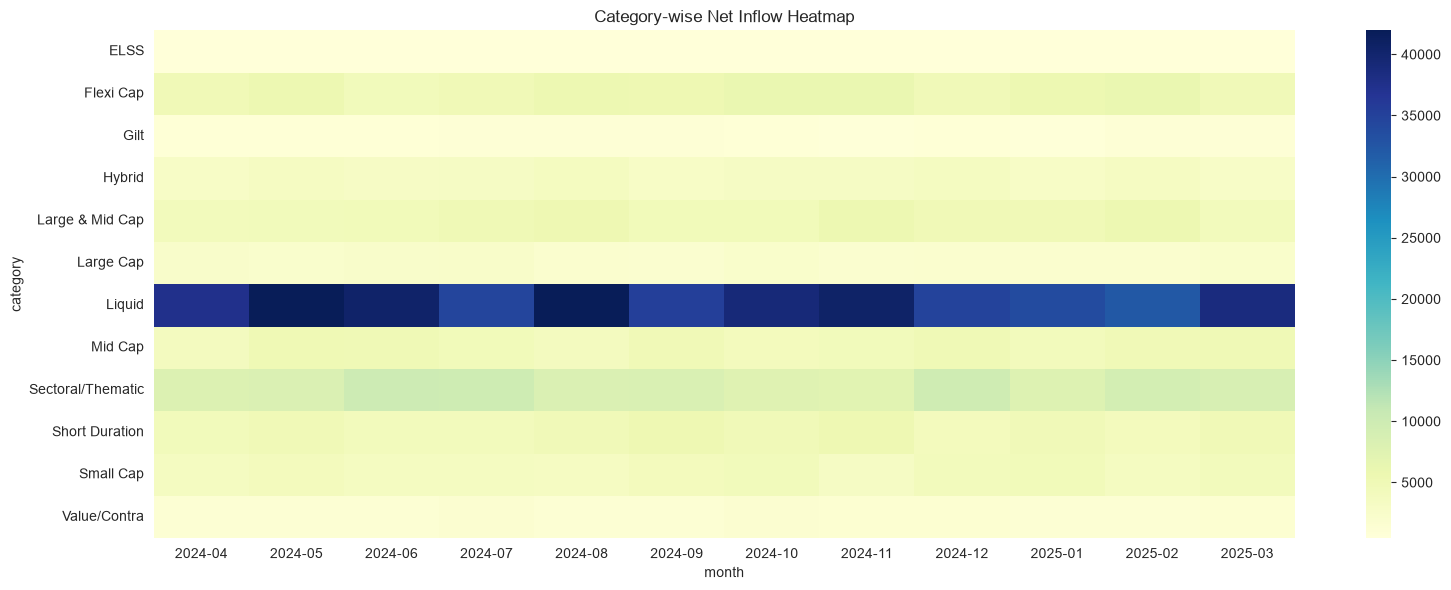

In [8]:
pivot = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title(
    "Category-wise Net Inflow Heatmap"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_heatmap.png"
)

plt.show()

### Insight 6

Liquid Funds received

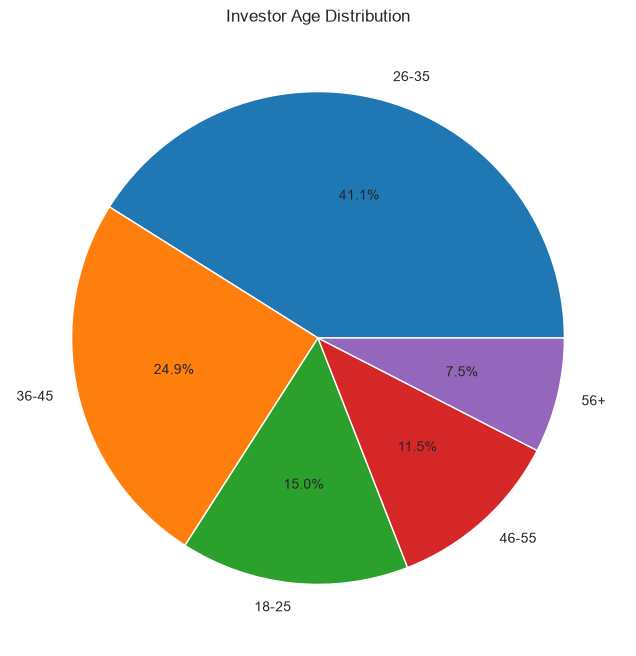

In [12]:
plt.figure(figsize=(8,8))

txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.savefig(
    "../reports/charts/age_distribution.png"
)

plt.show()

### Insight 7

The 26–35 and 36–45 age groups contribute the largest share of mutual fund investors, indicating strong participation from working professionals.

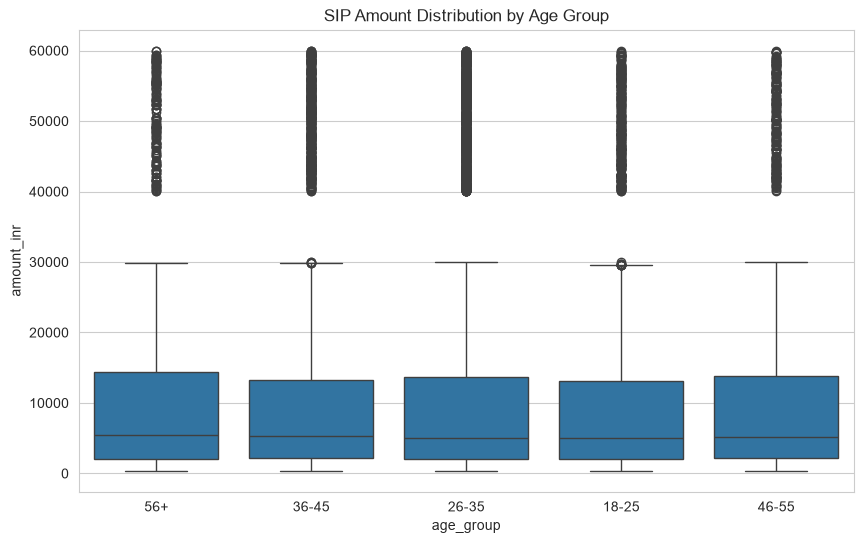

In [13]:
sip_txn = txn[
    txn["transaction_type"] == "Sip"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.savefig(
    "../reports/charts/sip_age_boxplot.png"
)

plt.show()

### Insight 8

SIP investment amounts vary across age groups, with older investors generally exhibiting higher investment capacities.

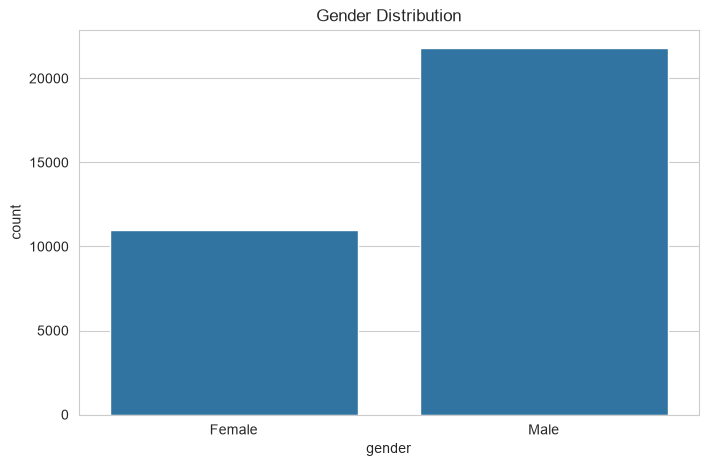

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=txn,
    x="gender"
)

plt.title("Gender Distribution")

plt.savefig(
    "../reports/charts/gender_split.png"
)

plt.show()

### Insight 9

Male and female investors both contribute significantly to mutual fund participation, reflecting broad retail adoption.

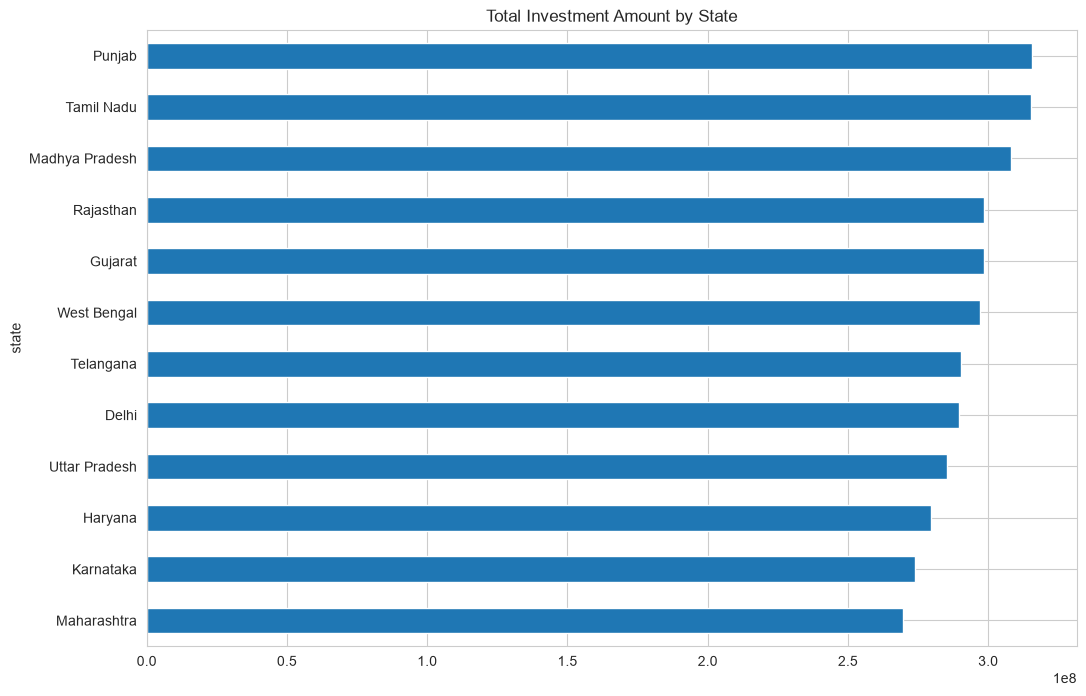

In [15]:
state_sip = txn.groupby(
    "state"
)["amount_inr"].sum()

state_sip.sort_values().plot(
    kind="barh",
    figsize=(12,8)
)

plt.title(
    "Total Investment Amount by State"
)

plt.savefig(
    "../reports/charts/state_sip.png"
)

plt.show()

### Insight 10

A few major states account for a disproportionately large share of total mutual fund investment activity.

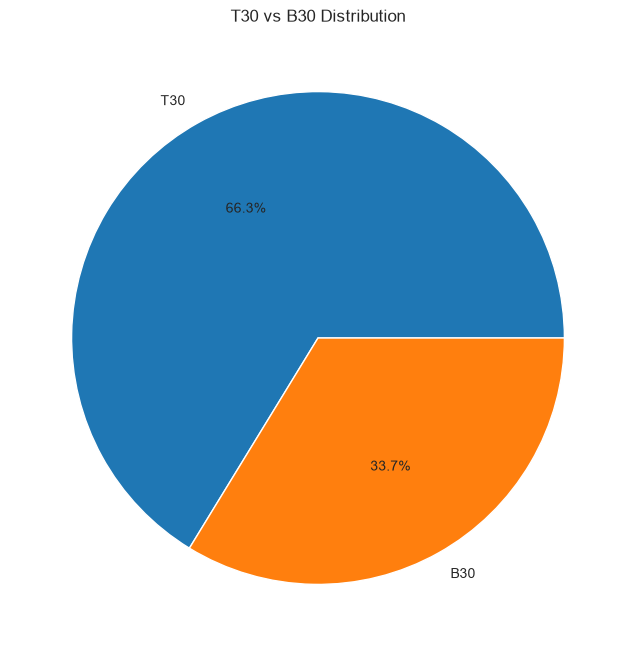

In [16]:
plt.figure(figsize=(8,8))

txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.savefig("../reports/charts/t30_b30.png")

plt.show()

### Insight 11

T30 cities contribute the majority of mutual fund investments, indicating stronger market penetration in urban regions.

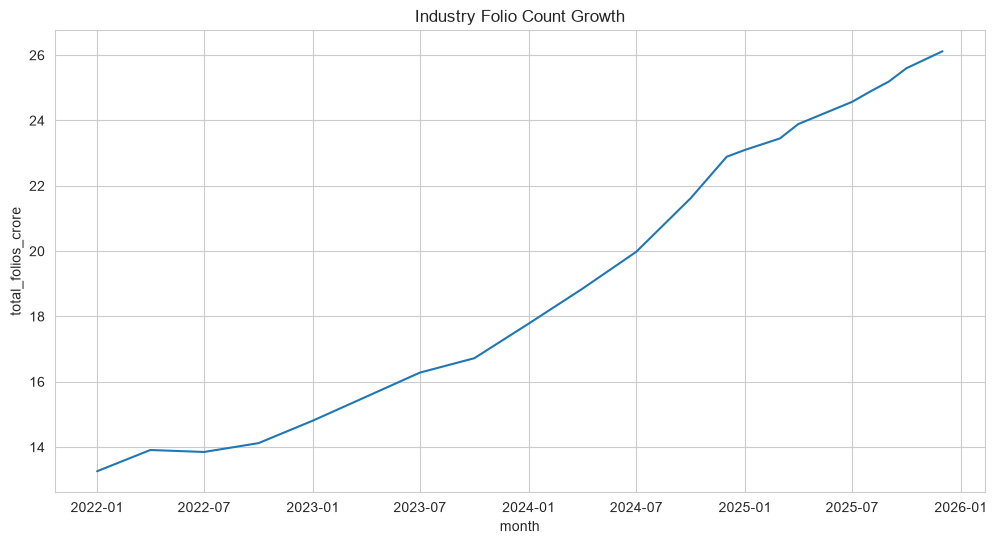

In [17]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore"
)

plt.title(
    "Industry Folio Count Growth"
)

plt.savefig(
    "../reports/charts/folio_growth.png"
)

plt.show()

### Insight 12

Industry folio count increased substantially from 2022 to 2025, reflecting rapid expansion in retail investor participation.

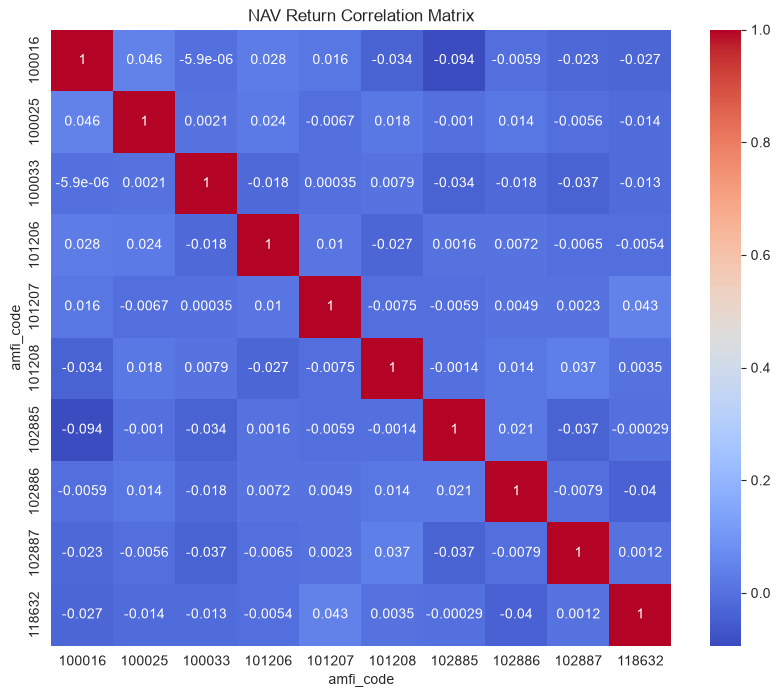

In [18]:
sample = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]

pivot = sample.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.savefig(
    "../reports/charts/correlation_matrix.png"
)

plt.show()

### Insight 13

Most equity-oriented funds exhibit positive return correlations, indicating sensitivity to common market movements.

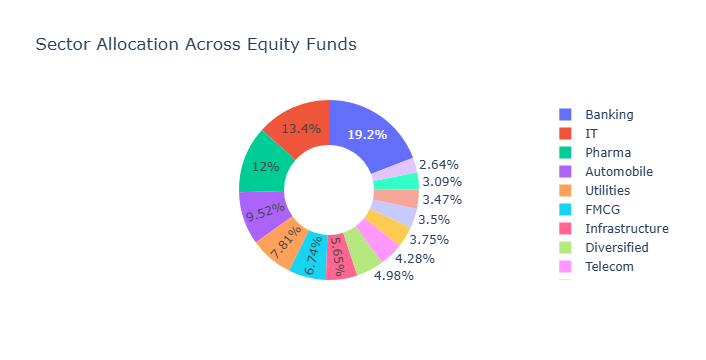

In [20]:
sector = hold.groupby(
    "sector"
)["weight_pct"].sum()

fig = px.pie(
    values=sector.values,
    names=sector.index,
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.show()

### Insight 14

Banking, Financial Services, and diversified sectors account for a major share of portfolio allocations.

### Insight 15

The mutual fund industry demonstrated strong growth between 2022 and 2025, supported by rising SIP inflows, increasing folio counts, expanding AUM, and growing retail participation.

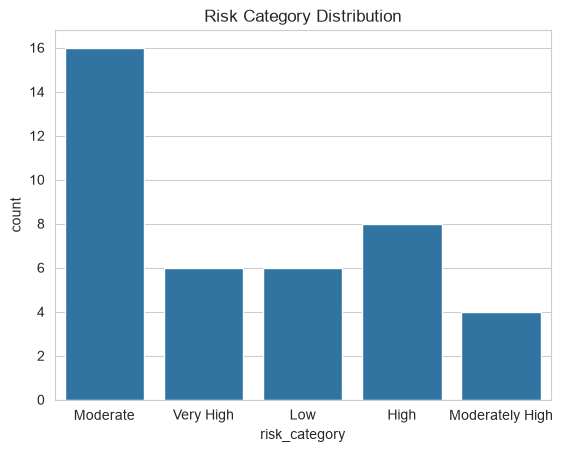

In [21]:
sns.countplot(
    data=fund,
    x="risk_category"
)

plt.title("Risk Category Distribution")
plt.show()

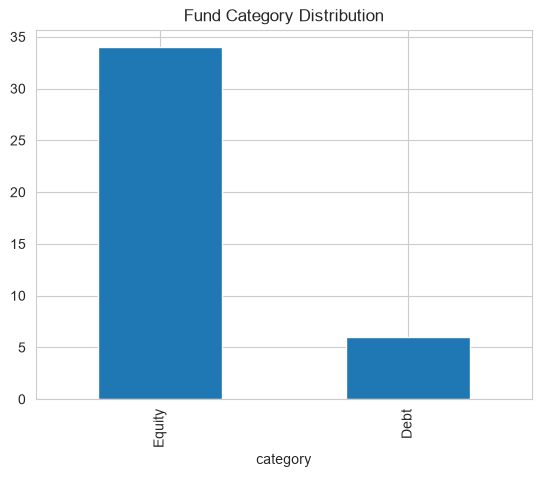

In [22]:
fund["category"].value_counts().plot(
    kind="bar"
)

plt.title("Fund Category Distribution")
plt.show()

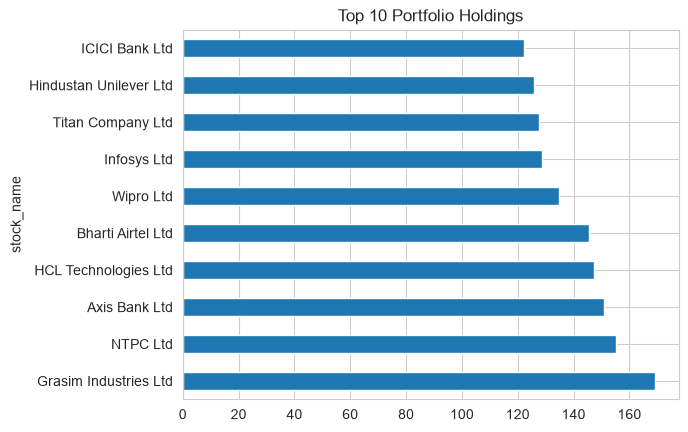

In [23]:
top_holdings = hold.groupby(
    "stock_name"
)["weight_pct"].sum().nlargest(10)

top_holdings.plot(
    kind="barh"
)

plt.title("Top 10 Portfolio Holdings")
plt.show()